In [1]:
import pandas as pd
import requests
import gc
import numpy as np


import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

# Load datasets

### miR part

In [12]:
#path = '/mnt/jack-5/amismailov/miRNA_study/'
#df_mir = pd.read_table('GTEx_miRNA_counts.txt.gz')
shared_targets = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/test_targets_v2.parquet').index

In [14]:
URS = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/URS.csv', index_col=0) # URS miRNA + name

In [15]:
df_mir

,Unnamed: 0,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
0,URS000012A1DD,0.000000,0.00000,1.996986,8.997750,0.000000,0.998424,0.999445,2.999279,33.999451,...,0.000000,0.000000,45.998415,294.996801,0.000000,2.997920,97.999318,3.996688,0.000000,0.00000
1,URS00002B452B,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
2,URS000023B77E,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.542499,...,0.000000,0.000000,276.985711,789.887832,0.000000,0.000000,140.604582,0.000000,0.000000,0.00000
3,URS00003DB428,0.433135,17.08322,25.965643,68.054364,1.892842,0.197676,2.217536,10.632999,926.520317,...,3.885708,4.401099,1216.693192,7181.571570,11.039381,8.041172,1068.452809,259.913674,0.505608,0.12878
4,URS00001BB658,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22477,chr10:1049289-1049310(+),4.000000,0.00000,2.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,0.000000,4.000000,0.000000,1.000000,0.000000,0.00000
22478,chr10:73782300-73782323(+),4.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000
22479,chr14:36204556-36204577(+),0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
22480,chr17:44266999-44267018(+),2.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


In [16]:
df_mir = df_mir.rename(columns={'Unnamed: 0' : 'miRNA'})
df_mir.index = df_mir.pop('miRNA')
df_mir.head(5)

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
URS000012A1DD,0.000000,0.00000,1.996986,8.997750,0.000000,0.998424,0.999445,2.999279,33.999451,0.999768,...,0.000000,0.000000,45.998415,294.996801,0.000000,2.997920,97.999318,3.996688,0.000000,0.00000
URS00002B452B,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
URS000023B77E,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.542499,0.000000,...,0.000000,0.000000,276.985711,789.887832,0.000000,0.000000,140.604582,0.000000,0.000000,0.00000
URS00003DB428,0.433135,17.08322,25.965643,68.054364,1.892842,0.197676,2.217536,10.632999,926.520317,8.381936,...,3.885708,4.401099,1216.693192,7181.571570,11.039381,8.041172,1068.452809,259.913674,0.505608,0.12878
URS00001BB658,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


In [6]:
df_mir.shape

(22482, 16761)

In [17]:
URS

,URS,miRNA_name
0,URS00002B452B,Hsa-Mir-8-P1a_3p
1,URS000023B77E,hsa-miR-200a-5p
2,URS00003DB428,Hsa-Mir-8-P2a_3p
3,URS00001BB658,Hsa-Mir-8-P3a_5p
4,URS000055BBE5,hsa-miR-429
...,...,...
879,URS00001F7A91,Hsa-Mir-452-v1_3p
880,URS0000D523DA,Hsa-Mir-452-v1_5p
881,URS0000D52745,Hsa-Mir-105-P2_3p
882,URS0000D4F80A,Hsa-Mir-105-P2_5p


## miRNA CPM with full list of detected genes

In [185]:
counts_per_sample = df_mir.sum(axis=0)
cpm = df_mir.divide(counts_per_sample, axis=1) * 1e6
cpm = cpm.fillna(0.0)
cpm.shape

(22482, 16761)

In [186]:
cpm

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
URS000012A1DD,0.000000,0.000000,1.013174,18.195378,0.000000,0.967391,0.948139,3.616156,39.249255,2.397885,...,0.000000,0.000000,44.663515,146.321507,0.000000,1.712156,133.255480,2.058193,0.000000,0.000000
URS00002B452B,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
URS000023B77E,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,161.089049,0.000000,...,0.000000,0.000000,268.947429,391.792648,0.000000,0.000000,191.188382,0.000000,0.000000,0.000000
URS00003DB428,0.611819,4.355031,13.173710,137.620504,1.749636,0.191532,2.103701,12.819942,1069.582940,20.103581,...,3.429127,5.344085,1181.384065,3562.134806,6.148508,4.592429,1452.838594,133.848981,0.622498,0.217265
URS00001BB658,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr10:1049289-1049310(+),5.650149,0.000000,1.014703,2.022214,0.000000,0.968918,0.000000,0.000000,0.000000,0.000000,...,0.882497,0.000000,0.000000,0.496010,0.000000,2.284458,0.000000,0.514975,0.000000,0.000000
chr10:73782300-73782323(+),5.650149,0.254930,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.882497,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.231187,0.000000
chr14:36204556-36204577(+),0.000000,0.254930,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [187]:
cpm = cpm[cpm.index.isin(URS['URS'])] # after CPM we can filter out indefined genes
cpm

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
URS000012A1DD,0.000000,0.000000,1.013174,18.195378,0.000000,0.967391,0.948139,3.616156,39.249255,2.397885,...,0.000000,0.000000,44.663515,146.321507,0.000000,1.712156,133.255480,2.058193,0.000000,0.000000
URS00002B452B,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
URS000023B77E,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,161.089049,0.000000,...,0.000000,0.000000,268.947429,391.792648,0.000000,0.000000,191.188382,0.000000,0.000000,0.000000
URS00003DB428,0.611819,4.355031,13.173710,137.620504,1.749636,0.191532,2.103701,12.819942,1069.582940,20.103581,...,3.429127,5.344085,1181.384065,3562.134806,6.148508,4.592429,1452.838594,133.848981,0.622498,0.217265
URS00001BB658,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URS0000D52200,1.239757,0.000000,0.000000,174.300925,13.121832,98.780807,57.781774,437.056111,49.459609,13.660222,...,62.345985,27.638507,49.764675,27.563167,20.855098,1.733134,1234.956580,112.483666,29.094164,320.217104
URS00001F7A91,0.000000,0.000000,0.000000,7.382158,0.000000,1.538685,10.279943,52.271006,4.049440,1.100629,...,5.223447,2.104045,4.447225,0.000000,0.105481,0.268406,33.163171,2.934845,0.000000,10.707523
URS0000D523DA,0.000000,4.902017,1.092383,107.920849,10.166093,31.706736,51.238193,459.319317,39.456446,11.436162,...,86.332622,19.298814,39.054133,13.029146,7.655856,8.137740,278.262993,22.007924,12.591499,78.666755


In [188]:
annotation = pd.read_table('annotation.txt', low_memory=False)

In [189]:
set_mir = cpm.columns.tolist()
#set_rna = df_genes.columns.tolist()[2:]
#annot = annotation['SAMPID'].tolist()

In [16]:
cols = ['SAMPID', 'SMTS', 'SMTSD']

# miRNA table make up

In [190]:
mir_annot_cols = annotation[annotation['SAMPID'].isin(set_mir)][cols]
mir_annot_cols

,SAMPID,SMTS,SMTSD
1634,GTEX-1117F-0005-SM-GMJZF,Blood,Whole Blood
1643,GTEX-1117F-0011-R3a-SM-GM3E3,Brain,Brain - Anterior cingulate cortex (BA24)
1647,GTEX-1117F-0011-R7a-SM-GLFXK,Brain,Brain - Putamen (basal ganglia)
1651,GTEX-1117F-0226-SM-DEURW,Adipose Tissue,Adipose - Subcutaneous
1653,GTEX-1117F-0426-SM-GAPMD,Muscle,Muscle - Skeletal
...,...,...,...
48001,GTEX-ZZPU-2126-SM-DEUQ2,Ovary,Ovary
48004,GTEX-ZZPU-2226-SM-EAIMP,Vagina,Vagina
48008,GTEX-ZZPU-2426-SM-GEGOG,Blood Vessel,Artery - Tibial
48011,GTEX-ZZPU-2626-SM-F4GMZ,Muscle,Muscle - Skeletal


In [191]:
cpm = cpm.transpose() 
cpm.insert(0, 'SAMPID', cpm.index.tolist()) 
cpm.head()

miRNA,SAMPID,URS000012A1DD,URS00002B452B,URS000023B77E,URS00003DB428,URS00001BB658,URS000055BBE5,URS00002E99CB,URS0000EFE3BE,URS000040249F,...,URS00001AADF2,URS000076CC56,URS000075C77C,URS000075B406,URS0000D547AD,URS0000D52200,URS00001F7A91,URS0000D523DA,URS0000D52745,URS0000D4F80A
GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0005-SM-GMJZF,0.000000,0.0,0.0,0.611819,0.0,1.093940,1.360059,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,1.239757,0.000000,0.000000,0.000000,0.000000
GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R3a-SM-GM3E3,0.000000,0.0,0.0,4.355031,0.0,0.535683,0.000000,0.0,0.127404,...,0.000000,0.0,0.0,0.0,0.381942,0.000000,0.000000,4.902017,0.764461,93.158749
GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0011-R7a-SM-GLFXK,1.013174,0.0,0.0,13.173710,0.0,4.984373,0.000000,0.0,0.253633,...,21.464086,0.0,0.0,0.0,0.253362,0.000000,0.000000,1.092383,0.000000,27.264117
GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0226-SM-DEURW,18.195378,0.0,0.0,137.620504,0.0,62.962721,0.734996,0.0,4.044302,...,0.000000,0.0,0.0,0.0,13.143459,174.300925,7.382158,107.920849,0.000000,0.000000
GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0426-SM-GAPMD,0.000000,0.0,0.0,1.749636,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,1.848461,13.121832,0.000000,10.166093,0.000000,0.279897


In [192]:
cpm = pd.merge(
    cpm,
    mir_annot_cols[['SAMPID', 'SMTSD']],
    on='SAMPID',
    how='left',      
    validate='one_to_one'  
)

In [193]:
cpm.insert(0, 'SMTSD', cpm.pop('SMTSD'))
cpm.pop('SAMPID')
cpm = cpm.sort_values('SMTSD')
cpm.head()

,SMTSD,URS000012A1DD,URS00002B452B,URS000023B77E,URS00003DB428,URS00001BB658,URS000055BBE5,URS00002E99CB,URS0000EFE3BE,URS000040249F,...,URS00001AADF2,URS000076CC56,URS000075C77C,URS000075B406,URS0000D547AD,URS0000D52200,URS00001F7A91,URS0000D523DA,URS0000D52745,URS0000D4F80A
16760,Adipose - Subcutaneous,0.000000,0.0,0.0,0.217265,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,8.857020,320.217104,10.707523,78.666755,0.0,0.0
10256,Adipose - Subcutaneous,0.000000,0.0,0.0,2.644610,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,69.031958,1248.683422,114.020638,577.080474,0.0,0.0
6815,Adipose - Subcutaneous,2.483894,0.0,0.0,6.649370,0.0,1.384893,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,20.825596,715.631157,34.365240,241.663321,0.0,0.0
2154,Adipose - Subcutaneous,0.000000,0.0,0.0,1.948897,0.0,1.805539,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,26.084873,385.873572,26.664809,205.941769,0.0,0.0
6769,Adipose - Subcutaneous,0.000000,0.0,0.0,2.512387,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.872188,360.731218,45.540404,200.198963,0.0,0.0


In [194]:
rename_URS = {}
for urs in cpm.columns.tolist()[1:]:
    rename_URS.setdefault(urs, None)
    rename_URS[urs] = (URS[URS['URS'] == urs]['miRNA_name'].item()).lower()
rename_URS

{'URS000012A1DD': 'hsa-mir-200b-5p',
 'URS00002B452B': 'hsa-mir-8-p1a_3p',
 'URS000023B77E': 'hsa-mir-200a-5p',
 'URS00003DB428': 'hsa-mir-8-p2a_3p',
 'URS00001BB658': 'hsa-mir-8-p3a_5p',
 'URS000055BBE5': 'hsa-mir-429',
 'URS00002E99CB': 'hsa-mir-551a',
 'URS0000EFE3BE': 'hsa-mir-551-p1_5p',
 'URS000040249F': 'hsa-mir-34-p1_3p',
 'URS000030BD69': 'hsa-mir-34a-5p',
 'URS0000EFC8B5': 'hsa-mir-552_3p',
 'URS00005AD632': 'hsa-mir-552_5p',
 'URS00001E2F7A': 'hsa-mir-5581-3p',
 'URS0000EFCFBB': 'hsa-mir-5581_5p',
 'URS00001B2024': 'hsa-mir-30-p1d_5p',
 'URS00004DC6A5': 'hsa-mir-30e-3p',
 'URS00000980C2': 'hsa-mir-30-p2b_5p',
 'URS0000237FB8': 'hsa-mir-30c-1-3p',
 'URS00005FF45E': 'hsa-mir-101-p2-v1_3p',
 'URS00004D302A': 'hsa-mir-101-p1-v1_5p',
 'URS000021D7C8': 'hsa-mir-186-3p',
 'URS000015CB3A': 'hsa-mir-186_5p',
 'URS0000D54A4C': 'hsa-mir-760_5p',
 'URS000075BD83': 'hsa-mir-760_3p',
 'URS0000EFF083': 'hsa-mir-137-p1-v2_3p',
 'URS000075D65A': 'hsa-mir-137-p1-v1_5p',
 'URS000020E2DD': 'hsa

In [195]:
cpm = cpm.rename(columns=rename_URS)
cpm.head()

,SMTSD,hsa-mir-200b-5p,hsa-mir-8-p1a_3p,hsa-mir-200a-5p,hsa-mir-8-p2a_3p,hsa-mir-8-p3a_5p,hsa-mir-429,hsa-mir-551a,hsa-mir-551-p1_5p,hsa-mir-34-p1_3p,...,hsa-mir-514a-3p,hsa-mir-506-p1a2_5p,hsa-mir-2114-5p,hsa-mir-2114_3p,hsa-mir-224_3p,hsa-mir-224_5p,hsa-mir-452-v1_3p,hsa-mir-452-v1_5p,hsa-mir-105-p2_3p,hsa-mir-105-p2_5p
16760,Adipose - Subcutaneous,0.000000,0.0,0.0,0.217265,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,8.857020,320.217104,10.707523,78.666755,0.0,0.0
10256,Adipose - Subcutaneous,0.000000,0.0,0.0,2.644610,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,69.031958,1248.683422,114.020638,577.080474,0.0,0.0
6815,Adipose - Subcutaneous,2.483894,0.0,0.0,6.649370,0.0,1.384893,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,20.825596,715.631157,34.365240,241.663321,0.0,0.0
2154,Adipose - Subcutaneous,0.000000,0.0,0.0,1.948897,0.0,1.805539,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,26.084873,385.873572,26.664809,205.941769,0.0,0.0
6769,Adipose - Subcutaneous,0.000000,0.0,0.0,2.512387,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.872188,360.731218,45.540404,200.198963,0.0,0.0


In [196]:
cpm = cpm.transpose()
cpm.columns = cpm.iloc[0].tolist()
cpm = cpm.iloc[1:]
cpm.insert(0, 'miR', cpm.index)
cpm = cpm.reset_index(drop=True)
cpm

,miR,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
0,hsa-mir-200b-5p,0.0,0.0,2.483894,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.705361,0.0,1.814927,0.0,0.0,3.297834,1.265766,0.0,0.0
1,hsa-mir-8-p1a_3p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,hsa-mir-200a-5p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,hsa-mir-8-p2a_3p,0.217265,2.64461,6.64937,1.948897,2.512387,3.032402,0.0,4.464813,3.401184,...,0.0,16.012806,0.813489,0.0,1.688017,0.936875,10.149324,0.970443,0.237759,0.611819
4,hsa-mir-8-p3a_5p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,hsa-mir-224_5p,320.217104,1248.683422,715.631157,385.873572,360.731218,629.861614,1587.357773,846.774064,811.72588,...,0.0,2.531551,0.0,0.0,0.0,0.0,3.003887,0.0,0.318586,1.239757
880,hsa-mir-452-v1_3p,10.707523,114.020638,34.36524,26.664809,45.540404,34.317491,55.780225,56.145818,28.533197,...,2.386806,0.231212,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
881,hsa-mir-452-v1_5p,78.666755,577.080474,241.663321,205.941769,200.198963,314.59646,318.818128,427.063805,295.77679,...,2.011853,3.305664,0.0,0.0,0.0,0.457044,7.47254,0.0,0.763478,0.0
882,hsa-mir-105-p2_3p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [197]:
pattern = r'[-_](?:5p|3p)$'
cpm.insert(0, 'precursor', cpm['miR'].str.replace(pattern, '', regex=True))
cpm.head(5)        

,precursor,miR,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
0,hsa-mir-200b,hsa-mir-200b-5p,0.0,0.0,2.483894,0.0,0.0,0.0,0.0,0.0,...,0.0,1.705361,0.0,1.814927,0.0,0.0,3.297834,1.265766,0.0,0.0
1,hsa-mir-8-p1a,hsa-mir-8-p1a_3p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,hsa-mir-200a,hsa-mir-200a-5p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,hsa-mir-8-p2a,hsa-mir-8-p2a_3p,0.217265,2.64461,6.64937,1.948897,2.512387,3.032402,0.0,4.464813,...,0.0,16.012806,0.813489,0.0,1.688017,0.936875,10.149324,0.970443,0.237759,0.611819
4,hsa-mir-8-p3a,hsa-mir-8-p3a_5p,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [198]:
cpm.iloc[880:882]#['miR']

,precursor,miR,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
880,hsa-mir-452-v1,hsa-mir-452-v1_3p,10.707523,114.020638,34.36524,26.664809,45.540404,34.317491,55.780225,56.145818,...,2.386806,0.231212,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
881,hsa-mir-452-v1,hsa-mir-452-v1_5p,78.666755,577.080474,241.663321,205.941769,200.198963,314.59646,318.818128,427.063805,...,2.011853,3.305664,0.0,0.0,0.0,0.457044,7.47254,0.0,0.763478,0.0


In [199]:
df_indexed = cpm.set_index('precursor')

# Уберём старую колонку miR — она нам больше не нужна
df_indexed = df_indexed.drop(columns=['miR'])

# Группируем по индексу (по precursor) и складываем все числовые колонки
df_precursor = df_indexed.groupby(level=0, sort=False).sum()

In [200]:
df_precursor

,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
precursor,,,,,,,,,,,,,,,,,,,,,
hsa-mir-200b,0.0,0.0,2.483894,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.705361,0.0,1.814927,0.0,0.0,3.297834,1.265766,0.0,0.0
hsa-mir-8-p1a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hsa-mir-200a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hsa-mir-8-p2a,0.217265,2.64461,6.64937,1.948897,2.512387,3.032402,0.0,4.464813,3.401184,4.330013,...,0.0,16.012806,0.813489,0.0,1.688017,0.936875,10.149324,0.970443,0.237759,0.611819
hsa-mir-8-p3a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hsa-mir-506-p1a2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.852646,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hsa-mir-2114,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hsa-mir-224,329.074123,1317.71538,736.456753,411.958445,394.603406,662.389026,1622.451411,872.579098,839.639743,360.06694,...,1.0855,2.531551,0.0,0.0,0.0,0.288955,3.003887,0.0,0.318586,1.239757


In [201]:
df_precursor.loc['hsa-mir-452-v1']

Adipose - Subcutaneous     89.374278
Adipose - Subcutaneous    691.101112
Adipose - Subcutaneous    276.028561
Adipose - Subcutaneous    232.606578
Adipose - Subcutaneous    245.739368
                             ...    
Whole Blood                 0.457044
Whole Blood                  7.47254
Whole Blood                      0.0
Whole Blood                 0.763478
Whole Blood                      0.0
Name: hsa-mir-452-v1, Length: 16761, dtype: object

In [203]:
df_precursor = df_precursor.drop('error', axis='index')

In [205]:
df_precursor.to_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/GTEx_miR_CPM_expanded.csv')

# GTEX mRNA table make up: addind the description

In [150]:
df_genes = pd.read_csv(
    'GTEX_genex_counts.gct.gz',
    sep='\t',
    skiprows=2,
    low_memory=False
)

print(df_genes.shape)
df_genes.head(5)

(59033, 19790)


,Name,Description,GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R4b-SM-GI4VM,GTEX-1117F-0011-R5a-SM-GI4VW,GTEX-1117F-0011-R6a-SM-GI4VX,...,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2326-SM-GOQYU,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2526-SM-GOQZ3,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
0,ENSG00000223972.5,DDX11L1,0,0,0,0,0,1,0,2,...,0,0,0,0,0,0,0,1,1,1
1,ENSG00000227232.5,WASH7P,54,117,457,183,167,223,202,224,...,135,79,86,81,47,89,83,220,32,66
2,ENSG00000278267.1,MIR6859-1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ENSG00000243485.5,MIR1302-2HG,0,2,1,0,0,1,0,0,...,1,0,2,2,0,1,1,0,0,0
4,ENSG00000237613.2,FAM138A,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [151]:
delete_dots = lambda x: x.split('.')[0]
df_genes['Name'] = df_genes['Name'].apply(delete_dots)
df_genes.head()

,Name,Description,GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R4b-SM-GI4VM,GTEX-1117F-0011-R5a-SM-GI4VW,GTEX-1117F-0011-R6a-SM-GI4VX,...,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2326-SM-GOQYU,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2526-SM-GOQZ3,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
0,ENSG00000223972,DDX11L1,0,0,0,0,0,1,0,2,...,0,0,0,0,0,0,0,1,1,1
1,ENSG00000227232,WASH7P,54,117,457,183,167,223,202,224,...,135,79,86,81,47,89,83,220,32,66
2,ENSG00000278267,MIR6859-1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ENSG00000243485,MIR1302-2HG,0,2,1,0,0,1,0,0,...,1,0,2,2,0,1,1,0,0,0
4,ENSG00000237613,FAM138A,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [152]:
df_genes.drop('Description', axis=1, inplace=True)
df_genes.index = df_genes.pop('Name')
df_genes.head(5)

,GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R4b-SM-GI4VM,GTEX-1117F-0011-R5a-SM-GI4VW,GTEX-1117F-0011-R6a-SM-GI4VX,GTEX-1117F-0011-R7a-SM-H65ZK,GTEX-1117F-0226-SM-5GZZ7,...,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2326-SM-GOQYU,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2526-SM-GOQZ3,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
Name,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0,0,0,0,0,1,0,2,0,0,...,0,0,0,0,0,0,0,1,1,1
ENSG00000227232,54,117,457,183,167,223,202,224,152,202,...,135,79,86,81,47,89,83,220,32,66
ENSG00000278267,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000243485,0,2,1,0,0,1,0,0,1,1,...,1,0,2,2,0,1,1,0,0,0
ENSG00000237613,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [153]:
df_genes = df_genes.transpose()

In [154]:
df_genes.insert(0, 'SAMPID', df_genes.index)
df_genes.head()

Name,SAMPID,ENSG00000223972,ENSG00000227232,ENSG00000278267,ENSG00000243485,ENSG00000237613,ENSG00000268020,ENSG00000240361,ENSG00000186092,ENSG00000238009,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0005-SM-HL9SH,0,54,0,0,0,0,1,0,2,...,35228,0,0,0,5663,1533,0,14981,0,0
GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R10b-SM-GI4VE,0,117,0,2,0,0,1,3,2,...,1679305,2,4,0,326100,61881,11,805387,5,2
GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R11b-SM-GIN8R,0,457,0,1,0,2,3,7,1,...,2983666,5,0,9,617151,127312,40,1487388,10,17
GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R2b-SM-GI4VL,0,183,0,0,1,0,3,8,0,...,3859486,10,5,9,901474,191670,49,1934630,35,20
GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R3a-SM-GJ3PJ,0,167,0,0,0,0,3,3,0,...,2393153,3,2,5,439891,101022,29,1033244,5,12


In [155]:
annotation[annotation['SAMPID'].isin(df_genes.index)][['SAMPID', 'SMTSD']]

,SAMPID,SMTSD
1635,GTEX-1117F-0005-SM-HL9SH,Whole Blood
1638,GTEX-1117F-0011-R10b-SM-GI4VE,Brain - Frontal Cortex (BA9)
1640,GTEX-1117F-0011-R11b-SM-GIN8R,Brain - Cerebellar Hemisphere
1641,GTEX-1117F-0011-R2b-SM-GI4VL,Brain - Substantia nigra
1642,GTEX-1117F-0011-R3a-SM-GJ3PJ,Brain - Anterior cingulate cortex (BA24)
...,...,...
48005,GTEX-ZZPU-2326-SM-GOQYU,Nerve - Tibial
48006,GTEX-ZZPU-2426-SM-5E44I,Artery - Tibial
48009,GTEX-ZZPU-2526-SM-GOQZ3,Skin - Sun Exposed (Lower leg)
48010,GTEX-ZZPU-2626-SM-5E45Y,Muscle - Skeletal


In [156]:
df_genes = pd.merge(
    df_genes,
    annotation[annotation['SAMPID'].isin(df_genes.index)][['SAMPID', 'SMTSD']],
    on='SAMPID',
    how='left',      
    validate='one_to_one'  
)


In [157]:
df_genes.insert(1, 'SMTSD', df_genes.pop('SMTSD'))
df_genes.head()

,SAMPID,SMTSD,ENSG00000223972,ENSG00000227232,ENSG00000278267,ENSG00000243485,ENSG00000237613,ENSG00000268020,ENSG00000240361,ENSG00000186092,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,GTEX-1117F-0005-SM-HL9SH,Whole Blood,0,54,0,0,0,0,1,0,...,35228,0,0,0,5663,1533,0,14981,0,0
1,GTEX-1117F-0011-R10b-SM-GI4VE,Brain - Frontal Cortex (BA9),0,117,0,2,0,0,1,3,...,1679305,2,4,0,326100,61881,11,805387,5,2
2,GTEX-1117F-0011-R11b-SM-GIN8R,Brain - Cerebellar Hemisphere,0,457,0,1,0,2,3,7,...,2983666,5,0,9,617151,127312,40,1487388,10,17
3,GTEX-1117F-0011-R2b-SM-GI4VL,Brain - Substantia nigra,0,183,0,0,1,0,3,8,...,3859486,10,5,9,901474,191670,49,1934630,35,20
4,GTEX-1117F-0011-R3a-SM-GJ3PJ,Brain - Anterior cingulate cortex (BA24),0,167,0,0,0,0,3,3,...,2393153,3,2,5,439891,101022,29,1033244,5,12


In [158]:
df_genes = df_genes.sort_values(by='SMTSD')
df_genes.head()

,SAMPID,SMTSD,ENSG00000223972,ENSG00000227232,ENSG00000278267,ENSG00000243485,ENSG00000237613,ENSG00000268020,ENSG00000240361,ENSG00000186092,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
19787,GTEX-ZZPU-2726-SM-5NQ8O,Adipose - Subcutaneous,1,66,0,0,0,1,1,1,...,937401,0,0,1,346374,117878,47,721570,4,1
11303,GTEX-1J8EW-0226-SM-CYPSW,Adipose - Subcutaneous,0,114,0,0,1,0,0,1,...,1155158,0,0,1,182880,41521,8,760042,2,1
11293,GTEX-1J1R8-2226-SM-ARZMP,Adipose - Subcutaneous,1,122,0,0,0,1,1,1,...,654446,1,0,1,144853,37736,17,482696,0,3
11252,GTEX-1J1OQ-0326-SM-CYPTJ,Adipose - Subcutaneous,0,72,0,0,0,0,1,2,...,1851429,0,1,1,247614,53519,14,1016645,1,2
11222,GTEX-1IY9M-0226-SM-CMKHP,Adipose - Subcutaneous,0,88,1,0,0,0,0,0,...,612032,0,0,0,174315,50926,20,422825,0,1


In [159]:
from collections import Counter
ctr = Counter(df_genes['SMTSD'].tolist())
sample_frequency = dict(ctr)

new_samples=[]
for k, v in sample_frequency.items():
    for j in range(v):
        current_sample = f'{k}_{j}'
        new_samples.append(current_sample)

assert len(new_samples) == len(df_genes)

In [160]:
df_genes['SMTSD'] = new_samples
df_genes.pop('SAMPID')
df_genes.head(5)

,SMTSD,ENSG00000223972,ENSG00000227232,ENSG00000278267,ENSG00000243485,ENSG00000237613,ENSG00000268020,ENSG00000240361,ENSG00000186092,ENSG00000238009,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
19787,Adipose - Subcutaneous_0,1,66,0,0,0,1,1,1,7,...,937401,0,0,1,346374,117878,47,721570,4,1
11303,Adipose - Subcutaneous_1,0,114,0,0,1,0,0,1,6,...,1155158,0,0,1,182880,41521,8,760042,2,1
11293,Adipose - Subcutaneous_2,1,122,0,0,0,1,1,1,3,...,654446,1,0,1,144853,37736,17,482696,0,3
11252,Adipose - Subcutaneous_3,0,72,0,0,0,0,1,2,0,...,1851429,0,1,1,247614,53519,14,1016645,1,2
11222,Adipose - Subcutaneous_4,0,88,1,0,0,0,0,0,4,...,612032,0,0,0,174315,50926,20,422825,0,1


# GTEX mRNA table make up: TPM normalization across all ~60k genes!

In [161]:
df_genes.index = df_genes.pop('SMTSD')
df_genes = df_genes.transpose()
df_genes.head(5)

SMTSD,Adipose - Subcutaneous_0,Adipose - Subcutaneous_1,Adipose - Subcutaneous_2,Adipose - Subcutaneous_3,Adipose - Subcutaneous_4,Adipose - Subcutaneous_5,Adipose - Subcutaneous_6,Adipose - Subcutaneous_7,Adipose - Subcutaneous_8,Adipose - Subcutaneous_9,...,Whole Blood_793,Whole Blood_794,Whole Blood_795,Whole Blood_796,Whole Blood_797,Whole Blood_798,Whole Blood_799,Whole Blood_800,Whole Blood_801,Whole Blood_802
ENSG00000223972,1,0,1,0,0,0,0,0,0,0,...,0,2,0,0,1,0,1,1,1,0
ENSG00000227232,66,114,122,72,88,130,183,249,278,171,...,83,119,353,43,64,216,16,82,51,54
ENSG00000278267,0,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
ENSG00000243485,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
ENSG00000237613,0,1,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0


In [162]:
print(f'Size dataset before deduplix: {df_genes.shape}')
df_genes.insert(0, 'SMTSD', df_genes.index)
df_genes = df_genes.drop_duplicates('SMTSD')
df_genes.index = df_genes.pop('SMTSD')
print(f'Size dataset after deduplix: {df_genes.shape}')

Size dataset before deduplix: (59033, 19788)
Size dataset after deduplix: (58988, 19788)


In [163]:
df_genes.head(5)

SMTSD,Adipose - Subcutaneous_0,Adipose - Subcutaneous_1,Adipose - Subcutaneous_2,Adipose - Subcutaneous_3,Adipose - Subcutaneous_4,Adipose - Subcutaneous_5,Adipose - Subcutaneous_6,Adipose - Subcutaneous_7,Adipose - Subcutaneous_8,Adipose - Subcutaneous_9,...,Whole Blood_793,Whole Blood_794,Whole Blood_795,Whole Blood_796,Whole Blood_797,Whole Blood_798,Whole Blood_799,Whole Blood_800,Whole Blood_801,Whole Blood_802
SMTSD,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,1,0,1,0,0,0,0,0,0,0,...,0,2,0,0,1,0,1,1,1,0
ENSG00000227232,66,114,122,72,88,130,183,249,278,171,...,83,119,353,43,64,216,16,82,51,54
ENSG00000278267,0,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
ENSG00000243485,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
ENSG00000237613,0,1,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0


In [164]:
# gene length
gene_length = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/df_gene_mapping.parquet')
print(f'size: {gene_length.shape}')
gene_length.index = gene_length.pop('gene_id')
gene_length.head(2)

size: (78899, 3)


,gene_name,gene_length_kb
gene_id,,
ENSG00000142611,PRDM16,369.454
ENSG00000284616,None,5.467


In [165]:
share = set(df_genes.index.tolist()) & set(gene_length.index.tolist())
len(share)

57827

In [166]:
# фильтруем датасет так что бы сохранить только те гены, длины которых известны
df_genes = df_genes[df_genes.index.isin(share)]
df_genes.shape

(57827, 19788)

In [167]:
# фильтруем длины генов так что бы сохранить только те что есть в нашем датафрейме df_genes
gene_length = gene_length[gene_length.index.isin(share)]
gene_length.shape

(57827, 2)

In [168]:
gene_length.insert(0, 'gene_id', gene_length.index)
gene_length

,gene_id,gene_name,gene_length_kb
gene_id,,,
ENSG00000142611,ENSG00000142611,PRDM16,369.454
ENSG00000284616,ENSG00000284616,None,5.467
ENSG00000260972,ENSG00000260972,None,1.697
ENSG00000229280,ENSG00000229280,EEF1DP6,0.372
ENSG00000232596,ENSG00000232596,LINC01646,22.536
...,...,...,...
ENSG00000198695,ENSG00000198695,MT-ND6,0.525
ENSG00000210194,ENSG00000210194,MT-TE,0.069
ENSG00000198727,ENSG00000198727,MT-CYB,1.141


In [169]:
lengths = gene_length.set_index('gene_id')['gene_length_kb']
lengths

gene_id
ENSG00000142611    369.454
ENSG00000284616      5.467
ENSG00000260972      1.697
ENSG00000229280      0.372
ENSG00000232596     22.536
                    ...   
ENSG00000198695      0.525
ENSG00000210194      0.069
ENSG00000198727      1.141
ENSG00000210195      0.066
ENSG00000210196      0.068
Name: gene_length_kb, Length: 57827, dtype: float64

In [170]:
L = lengths.reindex(df_genes.index)
L

SMTSD
ENSG00000223972     1.661
ENSG00000227232    10.191
ENSG00000278267     0.068
ENSG00000243485     2.521
ENSG00000237613     3.043
                    ...  
ENSG00000198695     0.525
ENSG00000210194     0.069
ENSG00000198727     1.141
ENSG00000210195     0.066
ENSG00000210196     0.068
Name: gene_length_kb, Length: 57827, dtype: float64

In [171]:
df_genes.shape

(57827, 19788)

In [172]:
rpk_gtex = df_genes.div(L, axis=0)
scale = rpk_gtex.sum(axis=0).replace(0, np.nan)
tpm_gtex = rpk_gtex.div(scale, axis=1) * 1e6
tpm_gtex = tpm_gtex.fillna(0.0)
tpm_gtex

SMTSD,Adipose - Subcutaneous_0,Adipose - Subcutaneous_1,Adipose - Subcutaneous_2,Adipose - Subcutaneous_3,Adipose - Subcutaneous_4,Adipose - Subcutaneous_5,Adipose - Subcutaneous_6,Adipose - Subcutaneous_7,Adipose - Subcutaneous_8,Adipose - Subcutaneous_9,...,Whole Blood_793,Whole Blood_794,Whole Blood_795,Whole Blood_796,Whole Blood_797,Whole Blood_798,Whole Blood_799,Whole Blood_800,Whole Blood_801,Whole Blood_802
SMTSD,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972,0.054246,0.000000,0.070871,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.161340,0.000000,0.000000,0.064947,0.000000,0.051758,0.076128,0.088275,0.000000
ENSG00000227232,0.583530,0.965060,1.409238,0.455305,1.018168,0.835866,2.062372,2.433939,2.239464,2.145971,...,0.784634,1.564634,3.761469,0.421292,0.677470,2.241035,0.134975,1.017442,0.733769,0.433996
ENSG00000278267,0.000000,0.000000,0.000000,0.000000,1.733982,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.596948,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000243485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.032564,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.042791,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000237613,0.000000,0.028351,0.000000,0.000000,0.000000,0.000000,0.000000,0.032736,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.032812,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198695,20230.621466,6822.990804,8461.312447,6569.553657,11437.569748,4728.692022,5338.248368,6573.868115,8074.852964,4348.826457,...,448.484928,3455.236741,2352.215529,3657.985159,3957.733880,6003.838017,373.195157,5188.230674,3355.882194,239.161523
ENSG00000210194,61.374015,10.002468,29.002872,13.075735,34.177036,5.697867,18.309490,47.642225,21.416057,20.388632,...,0.000000,7.767719,12.590427,17.364560,12.507426,30.647329,1.245954,14.660663,12.749943,0.000000
ENSG00000198727,56980.806652,57466.961175,49799.986841,57421.014610,43694.674283,54814.492594,34208.016806,33185.252571,38692.089527,46222.933631,...,2892.221852,9008.778838,9921.217903,5635.842240,12262.188795,9766.475114,1517.109635,12773.375829,6640.759311,1075.384117


In [65]:
tpm_gtex['Adipose - Subcutaneous_2'].sum()

999999.9999999984

In [216]:
tpm_gtex.to_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/GTEx_TPM_expanded.csv')

In [399]:
gc.collect()

0

# GTEx bootstrap merging

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

gtex_rna = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/GTEx_adaptive_K/GTEx_TPM_expanded.parquet')
gtex_mir = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/GTEx_miR_CPM_expanded.csv', index_col=0)

#gtex_rna = tpm_gtex
#gtex_mir = df_precursor

In [ ]:
gtex_mir_column_num = gtex_mir.index
gtex_rna_column_num = gtex_rna.index

In [32]:
foo = lambda x: x.split('.')[0]
del_suff = lambda x: x.split('_')[0]

gtex_mir.index = list(map(foo, gtex_mir.index))
gtex_rna.index = list(map(del_suff, gtex_rna.index))

In [52]:
gtex_mir

precursor,hsa-mir-200b,hsa-mir-8-p1a,hsa-mir-200a,hsa-mir-8-p2a,hsa-mir-8-p3a,hsa-mir-429,hsa-mir-551a,hsa-mir-551-p1,hsa-mir-34-p1,hsa-mir-34a,...,hsa-mir-506-p1c2,hsa-mir-506-p1c3,hsa-mir-509-3,hsa-mir-506-p1b,hsa-mir-514a,hsa-mir-506-p1a2,hsa-mir-2114,hsa-mir-224,hsa-mir-452-v1,hsa-mir-105-p2
Adipose - Subcutaneous,0.000000,0.0,0.0,0.217265,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,329.074123,89.374278,0.0
Adipose - Subcutaneous,0.000000,0.0,0.0,2.644610,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1317.715380,691.101112,0.0
Adipose - Subcutaneous,2.483894,0.0,0.0,6.649370,0.0,1.384893,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,736.456753,276.028561,0.0
Adipose - Subcutaneous,0.000000,0.0,0.0,1.948897,0.0,1.805539,0.000000,0.0,0.0,0.0,...,1.097474,0.0,0.0,0.0,0.0,0.0,0.0,411.958445,232.606578,0.0
Adipose - Subcutaneous,0.000000,0.0,0.0,2.512387,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,394.603406,245.739368,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Whole Blood,0.000000,0.0,0.0,0.936875,0.0,0.416430,2.190502,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.288955,0.457044,0.0
Whole Blood,3.297834,0.0,0.0,10.149324,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,3.003887,7.472540,0.0
Whole Blood,1.265766,0.0,0.0,0.970443,0.0,0.000000,9.966367,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
Whole Blood,0.000000,0.0,0.0,0.237759,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.318586,0.763478,0.0


In [49]:
# type of tissues 
len(set(list(map(foo, list(gtex_mir_column_num)))))

57

In [42]:
mir_tissues = set(list(map(foo, gtex_mir_column_num)))
rna_tissues = set(list(map(del_suff, gtex_rna_column_num)))

In [50]:
rna_tissues == mir_tissues

True

In [51]:
diff = set(mir_tissues) - set(rna_tissues)
diff

set()

In [210]:
############ FILTER
curr_cols = gtex_rna.columns.tolist()
curr_cols_filtered = list(map(del_suff, curr_cols))
gtex_rna.columns = curr_cols_filtered



True

In [53]:
gtex_mir

precursor,hsa-mir-200b,hsa-mir-8-p1a,hsa-mir-200a,hsa-mir-8-p2a,hsa-mir-8-p3a,hsa-mir-429,hsa-mir-551a,hsa-mir-551-p1,hsa-mir-34-p1,hsa-mir-34a,...,hsa-mir-506-p1c2,hsa-mir-506-p1c3,hsa-mir-509-3,hsa-mir-506-p1b,hsa-mir-514a,hsa-mir-506-p1a2,hsa-mir-2114,hsa-mir-224,hsa-mir-452-v1,hsa-mir-105-p2
Adipose - Subcutaneous,0.000000,0.0,0.0,0.217265,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,329.074123,89.374278,0.0
Adipose - Subcutaneous,0.000000,0.0,0.0,2.644610,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1317.715380,691.101112,0.0
Adipose - Subcutaneous,2.483894,0.0,0.0,6.649370,0.0,1.384893,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,736.456753,276.028561,0.0
Adipose - Subcutaneous,0.000000,0.0,0.0,1.948897,0.0,1.805539,0.000000,0.0,0.0,0.0,...,1.097474,0.0,0.0,0.0,0.0,0.0,0.0,411.958445,232.606578,0.0
Adipose - Subcutaneous,0.000000,0.0,0.0,2.512387,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,394.603406,245.739368,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Whole Blood,0.000000,0.0,0.0,0.936875,0.0,0.416430,2.190502,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.288955,0.457044,0.0
Whole Blood,3.297834,0.0,0.0,10.149324,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,3.003887,7.472540,0.0
Whole Blood,1.265766,0.0,0.0,0.970443,0.0,0.000000,9.966367,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
Whole Blood,0.000000,0.0,0.0,0.237759,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.318586,0.763478,0.0


In [54]:
from collections import Counter

counter_mir = dict(Counter(mir_cols))
counter_genes = dict(Counter(rna_cols))

In [56]:
ctr = {}
for tissue in diff:
    ctr.setdefault(tissue, None)
    ctr[tissue] = counter_genes[tissue]


In [67]:
set(counter_mir.keys()) -set(counter_genes.keys()) 

set()

In [69]:
tissues_remove = []
for tissue in set(counter_mir.keys()):
    if counter_mir[tissue] < 5:
        tissues_remove.append(tissue)
print(tissues_remove)

['Stomach - Mixed Cell', 'Stomach - Muscularis', 'Stomach - Mucosa']


In [71]:
gtex_mir=gtex_mir[~gtex_mir.index.isin(tissues_remove)]
gtex_rna=gtex_rna[~gtex_rna.index.isin(tissues_remove)]

# Find K

In [72]:
gtex_mir = gtex_mir.apply(pd.to_numeric, errors='coerce')
gtex_rna = gtex_rna.apply(pd.to_numeric, errors='coerce')

In [73]:
import importlib, scripts_GTEX
importlib.reload(scripts_GTEX)

# Считаем для всех тканей
results_k = {}
for tissue in gtex_mir.index.unique():
    tissue_data = gtex_mir.loc[tissue]
    # Проверка на случай, если в ткани всего 1 образец
    if len(tissue_data.shape) == 1 or tissue_data.shape[0] < 2:
        results_k[tissue] = 1
    else:
        results_k[tissue] = scripts_GTEX.find_optimal_k_refined(tissue_data)

# Выведем результат
print("Подобранные K для тканей (примеры):")
for t in list(results_k.keys())[:5]:
    print(f"{t}: K = {results_k[t]}")

Подобранные K для тканей (примеры):
Adipose - Subcutaneous: K = 10
Adipose - Visceral (Omentum): K = 8
Adrenal Gland: K = 10
Artery - Aorta: K = 6
Artery - Coronary: K = 9


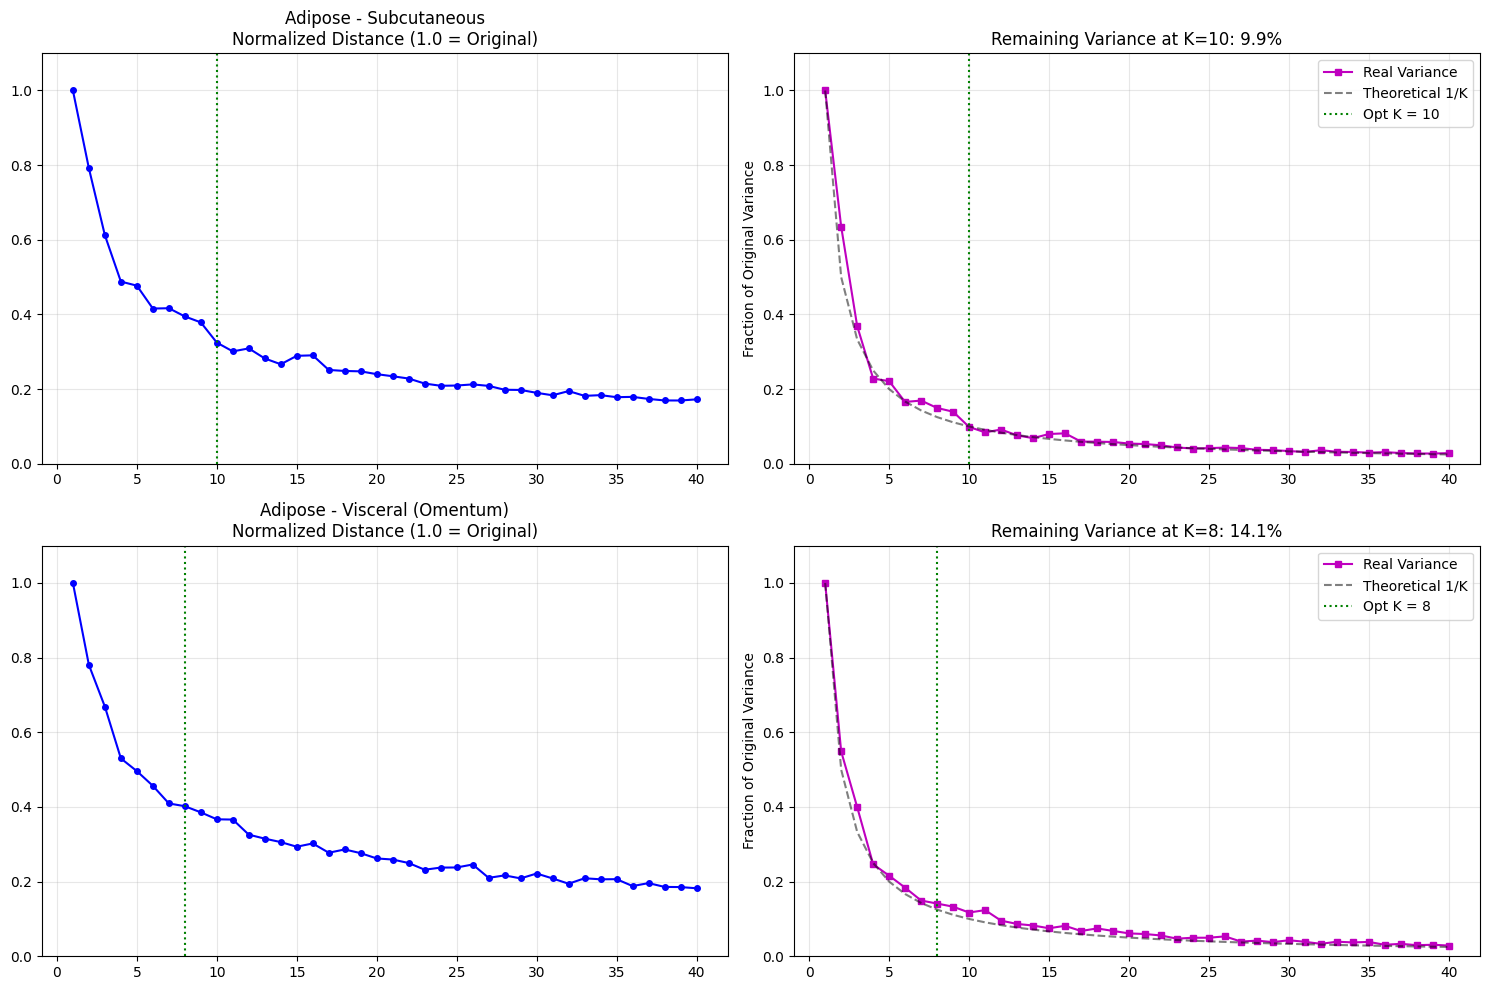

In [75]:
import importlib, scripts_GTEX
importlib.reload(scripts_GTEX)
scripts_GTEX.plot_normalized_optimization(gtex_mir, list(results_k.keys())[:2], results_k)

In [77]:
import importlib, scripts_GTEX
importlib.reload(scripts_GTEX)
scripts_GTEX.save_gtex_optimization_report(gtex_mir, results_k, output_dir='figures')

Начинаю генерацию отчета для 54 тканей...
Готово! Отчет сохранен по адресу: figures/GTEx_K_Optimization_Results.pdf


In [80]:
gtex_mir.shape

(16755, 606)

In [81]:
gtex_rna

SMTSD,ENSG00000223972,ENSG00000227232,ENSG00000278267,ENSG00000243485,ENSG00000237613,ENSG00000268020,ENSG00000240361,ENSG00000186092,ENSG00000233750,ENSG00000268903,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
Adipose - Subcutaneous,0.054246,0.583530,0.000000,0.0,0.000000,0.107265,0.095956,0.014610,0.212728,12.888803,...,61293.153156,0.000000,0.000000,1.269046,17223.557546,20230.621466,61.374015,56980.806652,5.460744,1.325033
Adipose - Subcutaneous,0.000000,0.965060,0.000000,0.0,0.028351,0.000000,0.000000,0.013989,0.203684,10.055461,...,72320.006641,0.000000,0.000000,1.215089,8707.115481,6822.990804,10.002468,57466.961175,2.614281,1.268695
Adipose - Subcutaneous,0.070871,1.409238,0.000000,0.0,0.000000,0.140140,0.125365,0.019088,0.061762,9.666871,...,55906.946466,1.706051,0.000000,1.657994,9410.451772,8461.312447,29.002872,49799.986841,0.000000,5.193421
Adipose - Subcutaneous,0.000000,0.455305,0.000000,0.0,0.000000,0.000000,0.068631,0.020900,0.033811,18.010372,...,86585.470634,0.000000,1.092283,0.907672,8806.517044,6569.553657,13.075735,57421.014610,0.976435,1.895432
Adipose - Subcutaneous,0.000000,1.018168,1.733982,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.811118,...,52369.497334,0.000000,0.000000,0.000000,11343.055580,11437.569748,34.177036,43694.674283,0.000000,1.733982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Whole Blood,0.000000,2.241035,0.000000,0.0,0.000000,0.125873,0.112602,0.051435,2.967855,1303.110221,...,17231.839920,0.000000,0.000000,0.000000,3210.919135,6003.838017,30.647329,9766.475114,0.000000,3.109802
Whole Blood,0.051758,0.134975,0.000000,0.0,0.000000,0.000000,0.091556,0.000000,0.157869,15.030657,...,2934.549059,0.000000,0.000000,0.000000,439.437950,373.195157,1.245954,1517.109635,1.302588,0.000000
Whole Blood,0.076128,1.017442,0.000000,0.0,0.000000,0.000000,0.269325,0.082016,7.861550,1822.864139,...,18944.567731,0.000000,2.143190,0.000000,2982.768356,5188.230674,14.660663,12773.375829,0.000000,0.000000
Whole Blood,0.088275,0.733769,0.000000,0.0,0.000000,0.000000,0.000000,0.023776,15.808659,584.749548,...,11087.481998,0.000000,0.000000,0.000000,2415.174879,3355.882194,12.749943,6640.759311,2.221581,0.000000


In [82]:
import importlib, scripts_GTEX
importlib.reload(scripts_GTEX)

supplementary_table = scripts_GTEX.generate_noise_reduction_stats(gtex_mir, results_k)
supplementary_table.to_csv('figures/Supplementary_Table_K_Optimization.csv', index=False)

In [145]:
len(results_k)

57

In [88]:
bootstraped_mir = scripts_GTEX.bootstrap_miRNA_adaptive(gtex_mir, gtex_rna.index, results_k)

Начинаю генерацию синтетических профилей для 19616 образцов...
Обработано 5000 образцов...
Обработано 10000 образцов...
Обработано 15000 образцов...
Сборка завершена. Итоговый размер: (19616, 606)


In [89]:
bootstraped_mir.shape

(19616, 606)

In [90]:
gtex_rna.shape

(19616, 57827)

In [91]:
bootstraped_mir

precursor,hsa-mir-200b,hsa-mir-8-p1a,hsa-mir-200a,hsa-mir-8-p2a,hsa-mir-8-p3a,hsa-mir-429,hsa-mir-551a,hsa-mir-551-p1,hsa-mir-34-p1,hsa-mir-34a,...,hsa-mir-506-p1c2,hsa-mir-506-p1c3,hsa-mir-509-3,hsa-mir-506-p1b,hsa-mir-514a,hsa-mir-506-p1a2,hsa-mir-2114,hsa-mir-224,hsa-mir-452-v1,hsa-mir-105-p2
Adipose - Subcutaneous,0.662015,0.0,0.000000,5.087834,0.0,1.182211,0.087116,0.0,0.321157,0.0,...,0.073612,0.243419,8.026640,0.025343,7.395062,0.104739,0.000000,608.457604,234.994613,0.000000
Adipose - Subcutaneous,4.003702,0.0,3.401033,102.053673,0.0,44.572539,0.085419,0.0,0.130427,0.0,...,0.198749,1.212648,3.576128,0.099843,18.919190,0.163037,0.152141,485.464249,222.156820,0.019240
Adipose - Subcutaneous,0.723753,0.0,0.000000,12.063703,0.0,5.534996,0.000000,0.0,0.397159,0.0,...,0.000000,0.854437,0.883675,0.000000,2.650062,0.000000,0.000000,839.556555,322.676866,0.000000
Adipose - Subcutaneous,0.158902,0.0,0.000000,2.197923,0.0,0.088316,0.032976,0.0,0.044759,0.0,...,0.377659,0.662238,1.248517,0.000000,5.250186,0.034914,0.105006,756.382547,248.138350,0.015917
Adipose - Subcutaneous,1.206095,0.0,0.000000,22.024980,0.0,6.650621,0.000000,0.0,0.207921,0.0,...,0.000000,0.216893,0.000000,0.000000,0.000000,0.053495,0.055574,531.663113,187.958486,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Whole Blood,0.146135,0.0,0.000000,1.002507,0.0,1.067451,2.601513,0.0,0.000000,0.0,...,0.062921,0.000000,0.000000,0.000000,0.139153,0.000000,0.000000,2.077034,0.444695,0.049323
Whole Blood,0.000000,0.0,0.048981,2.522739,0.0,0.511063,0.926977,0.0,0.000000,0.0,...,1.090806,1.347494,32.220419,0.046282,35.049214,0.306303,0.000000,0.840721,0.259850,0.000000
Whole Blood,0.286833,0.0,0.000000,3.343095,0.0,0.433244,4.564203,0.0,0.000000,0.0,...,0.028005,0.518492,9.302785,0.000000,10.135269,0.000000,0.000000,3.719930,2.534094,0.000000
Whole Blood,0.156205,0.0,0.000000,4.044578,0.0,2.028061,2.097623,0.0,0.000000,0.0,...,0.604318,1.422579,11.105502,0.076229,18.614323,0.141306,0.000000,1.416378,0.761804,0.273370


In [92]:
gtex_rna.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/GTEx_adaptive_K/GTEx_TPM_expanded.parquet')
bootstraped_mir.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/GTEx_adaptive_K/GTEx_CPM_boot.parquet')

# MAKE unique cols back

In [3]:
import pandas as pd
gtex_rna = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/GTEx_TPM_expanded.parquet')
bootstraped_mir = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/GTEx_adaptive_K/GTEx_CPM_boot.parquet')

In [6]:
from collections import Counter
ctr = Counter(gtex_rna.index.tolist())
sample_frequency = dict(ctr)

new_samples=[]
for k, v in sample_frequency.items():
    for j in range(v):
        current_sample = f'{k}_{j}'
        new_samples.append(current_sample)

assert len(new_samples) == len(gtex_rna)
gtex_rna.index = new_samples
gtex_rna

SMTSD,ENSG00000223972,ENSG00000227232,ENSG00000278267,ENSG00000243485,ENSG00000237613,ENSG00000268020,ENSG00000240361,ENSG00000186092,ENSG00000233750,ENSG00000268903,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
Adipose - Subcutaneous_0,0.054246,0.583530,0.000000,0.0,0.000000,0.107265,0.095956,0.014610,0.212728,12.888803,...,61293.153156,0.000000,0.000000,1.269046,17223.557546,20230.621466,61.374015,56980.806652,5.460744,1.325033
Adipose - Subcutaneous_1,0.000000,0.965060,0.000000,0.0,0.028351,0.000000,0.000000,0.013989,0.203684,10.055461,...,72320.006641,0.000000,0.000000,1.215089,8707.115481,6822.990804,10.002468,57466.961175,2.614281,1.268695
Adipose - Subcutaneous_2,0.070871,1.409238,0.000000,0.0,0.000000,0.140140,0.125365,0.019088,0.061762,9.666871,...,55906.946466,1.706051,0.000000,1.657994,9410.451772,8461.312447,29.002872,49799.986841,0.000000,5.193421
Adipose - Subcutaneous_3,0.000000,0.455305,0.000000,0.0,0.000000,0.000000,0.068631,0.020900,0.033811,18.010372,...,86585.470634,0.000000,1.092283,0.907672,8806.517044,6569.553657,13.075735,57421.014610,0.976435,1.895432
Adipose - Subcutaneous_4,0.000000,1.018168,1.733982,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.811118,...,52369.497334,0.000000,0.000000,0.000000,11343.055580,11437.569748,34.177036,43694.674283,0.000000,1.733982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Whole Blood_798,0.000000,2.241035,0.000000,0.0,0.000000,0.125873,0.112602,0.051435,2.967855,1303.110221,...,17231.839920,0.000000,0.000000,0.000000,3210.919135,6003.838017,30.647329,9766.475114,0.000000,3.109802
Whole Blood_799,0.051758,0.134975,0.000000,0.0,0.000000,0.000000,0.091556,0.000000,0.157869,15.030657,...,2934.549059,0.000000,0.000000,0.000000,439.437950,373.195157,1.245954,1517.109635,1.302588,0.000000
Whole Blood_800,0.076128,1.017442,0.000000,0.0,0.000000,0.000000,0.269325,0.082016,7.861550,1822.864139,...,18944.567731,0.000000,2.143190,0.000000,2982.768356,5188.230674,14.660663,12773.375829,0.000000,0.000000
Whole Blood_801,0.088275,0.733769,0.000000,0.0,0.000000,0.000000,0.000000,0.023776,15.808659,584.749548,...,11087.481998,0.000000,0.000000,0.000000,2415.174879,3355.882194,12.749943,6640.759311,2.221581,0.000000


In [10]:
from collections import Counter
ctr = Counter(bootstraped_mir.index.tolist())
sample_frequency = dict(ctr)

new_samples=[]
for k, v in sample_frequency.items():
    for j in range(v):
        current_sample = f'{k}_{j}'
        new_samples.append(current_sample)

assert len(new_samples) == len(gtex_rna)
bootstraped_mir.index = new_samples
bootstraped_mir

precursor,hsa-mir-200b,hsa-mir-8-p1a,hsa-mir-200a,hsa-mir-8-p2a,hsa-mir-8-p3a,hsa-mir-429,hsa-mir-551a,hsa-mir-551-p1,hsa-mir-34-p1,hsa-mir-34a,...,hsa-mir-506-p1c2,hsa-mir-506-p1c3,hsa-mir-509-3,hsa-mir-506-p1b,hsa-mir-514a,hsa-mir-506-p1a2,hsa-mir-2114,hsa-mir-224,hsa-mir-452-v1,hsa-mir-105-p2
Adipose - Subcutaneous_0,0.662015,0.0,0.000000,5.087834,0.0,1.182211,0.087116,0.0,0.321157,0.0,...,0.073612,0.243419,8.026640,0.025343,7.395062,0.104739,0.000000,608.457604,234.994613,0.000000
Adipose - Subcutaneous_1,4.003702,0.0,3.401033,102.053673,0.0,44.572539,0.085419,0.0,0.130427,0.0,...,0.198749,1.212648,3.576128,0.099843,18.919190,0.163037,0.152141,485.464249,222.156820,0.019240
Adipose - Subcutaneous_2,0.723753,0.0,0.000000,12.063703,0.0,5.534996,0.000000,0.0,0.397159,0.0,...,0.000000,0.854437,0.883675,0.000000,2.650062,0.000000,0.000000,839.556555,322.676866,0.000000
Adipose - Subcutaneous_3,0.158902,0.0,0.000000,2.197923,0.0,0.088316,0.032976,0.0,0.044759,0.0,...,0.377659,0.662238,1.248517,0.000000,5.250186,0.034914,0.105006,756.382547,248.138350,0.015917
Adipose - Subcutaneous_4,1.206095,0.0,0.000000,22.024980,0.0,6.650621,0.000000,0.0,0.207921,0.0,...,0.000000,0.216893,0.000000,0.000000,0.000000,0.053495,0.055574,531.663113,187.958486,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Whole Blood_798,0.146135,0.0,0.000000,1.002507,0.0,1.067451,2.601513,0.0,0.000000,0.0,...,0.062921,0.000000,0.000000,0.000000,0.139153,0.000000,0.000000,2.077034,0.444695,0.049323
Whole Blood_799,0.000000,0.0,0.048981,2.522739,0.0,0.511063,0.926977,0.0,0.000000,0.0,...,1.090806,1.347494,32.220419,0.046282,35.049214,0.306303,0.000000,0.840721,0.259850,0.000000
Whole Blood_800,0.286833,0.0,0.000000,3.343095,0.0,0.433244,4.564203,0.0,0.000000,0.0,...,0.028005,0.518492,9.302785,0.000000,10.135269,0.000000,0.000000,3.719930,2.534094,0.000000
Whole Blood_801,0.156205,0.0,0.000000,4.044578,0.0,2.028061,2.097623,0.0,0.000000,0.0,...,0.604318,1.422579,11.105502,0.076229,18.614323,0.141306,0.000000,1.416378,0.761804,0.273370


In [7]:
assert all(bootstraped_mir.index == gtex_rna.index)

In [12]:
gtex_rna.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/GTEx_TPM_expanded.parquet')
bootstraped_mir.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/GTEx_adaptive_K/GTEx_CPM_boot.parquet')